Healthcare Churn Analysis - Predicting Missed Appointments


In [46]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
%matplotlib inline

In [47]:
#Load the dataset into a pandas dataframe
data = pd.read_csv("Medical_Appointment.csv")
data.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


Data Cleaning 


In [48]:
#Check shape of the dataset
data.shape
print(f"The dataset contains {data.shape[0]} rows and {data.shape[1]} columns.")

The dataset contains 110527 rows and 14 columns.


In [49]:
#Data cleaning and preprocessing
#check for missing values
#check for duplicates
data.isnull().sum()
data.duplicated().sum()
print(f"The dataset contains {data.duplicated().sum()} duplicate rows.")

The dataset contains 0 duplicate rows.


In [50]:
#check columns
data.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

In [51]:
data.rename(columns=
    {'Hipertension': 'Hypertension',
    'Handcap': 'Handicap'}, inplace=True)

data.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No-show'],
      dtype='object')

In [52]:
#replaace invalid age values with median age (<0 - 15)
data["Age"].min()
data["Age"].max()
negative_ages = data[data["Age"] < 0]
negative_ages.sum().count()
print(f"The dataset contains {negative_ages.sum().count()} negative age values.")

The dataset contains 14 negative age values.


In [53]:
median_age = data['Age'].median()
data.loc[data['Age'] <= 15, 'Age'] = median_age

In [54]:
data['Age'].min()


np.int64(16)

In [55]:
#convert date column to datetime format
data["ScheduledDay"] = pd.to_datetime(data["ScheduledDay"]) 
data["AppointmentDay"] = pd.to_datetime(data["AppointmentDay"])
data['AppointmentDay']
data['ScheduledDay']

0        2016-04-29 18:38:08+00:00
1        2016-04-29 16:08:27+00:00
2        2016-04-29 16:19:04+00:00
3        2016-04-29 17:29:31+00:00
4        2016-04-29 16:07:23+00:00
                    ...           
110522   2016-05-03 09:15:35+00:00
110523   2016-05-03 07:27:33+00:00
110524   2016-04-27 16:03:52+00:00
110525   2016-04-27 15:09:23+00:00
110526   2016-04-27 13:30:56+00:00
Name: ScheduledDay, Length: 110527, dtype: datetime64[ns, UTC]

In [56]:
#create a new feature - WaitDays (in days) between scheduling and appointment
data["WaitDays"] = (data["AppointmentDay"] - data["ScheduledDay"]).dt.days
data['WaitDays']
data.loc[data['WaitDays'] < 0, 'WaitDays'] = 0

In [57]:
data[["ScheduledDay", "AppointmentDay", "WaitDays"]].head(2)

,ScheduledDay,AppointmentDay,WaitDays
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,0
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,0


In [58]:
data['Handicap'].value_counts()

Handicap
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64

In [59]:
data['Has_Handicap'] = data['Handicap'].apply(lambda x: 1 if x > 0 else 0)
data['Has_Handicap'].value_counts()

Has_Handicap
0    108286
1      2241
Name: count, dtype: int64

Exploratory Analysis

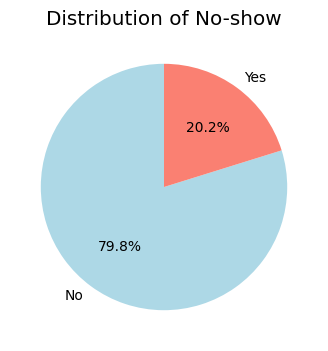

In [60]:
#check target variable distribution
data.head(2)
colors = ['#2ecc71', '#e74c3c'] 
data['No-show'].value_counts()
plt.figure(figsize=(5,4))
data['No-show'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])
plt.title('Distribution of No-show')
plt.ylabel('')
plt.show()

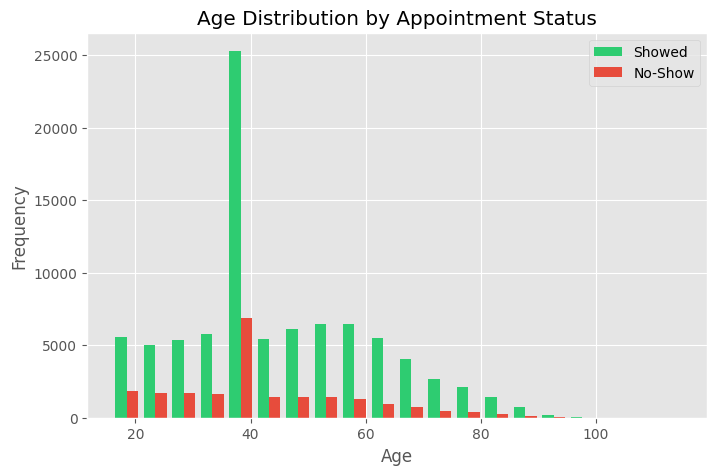

In [61]:
plt.figure(figsize=(8,5))
plt.hist([data[data['No-show'] == 'No']['Age'], 
          data[data['No-show'] == 'Yes']['Age']], 
         bins=20, 
         color=['#2ecc71', '#e74c3c'],
         label=['Showed', 'No-Show'])
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Appointment Status')
plt.legend()
plt.show()

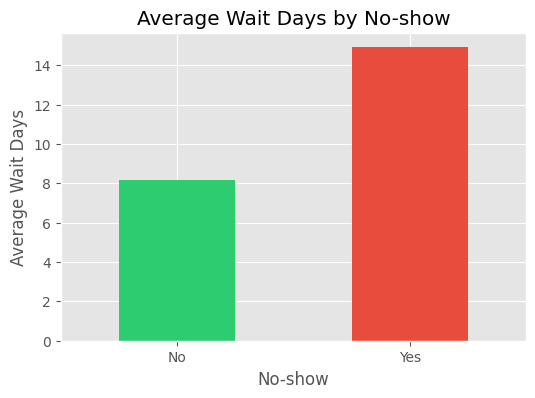

In [62]:
plt.figure(figsize=(6,4))
data.groupby('No-show')['WaitDays'].mean().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Average Wait Days by No-show')
plt.ylabel('Average Wait Days')
plt.xticks(rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

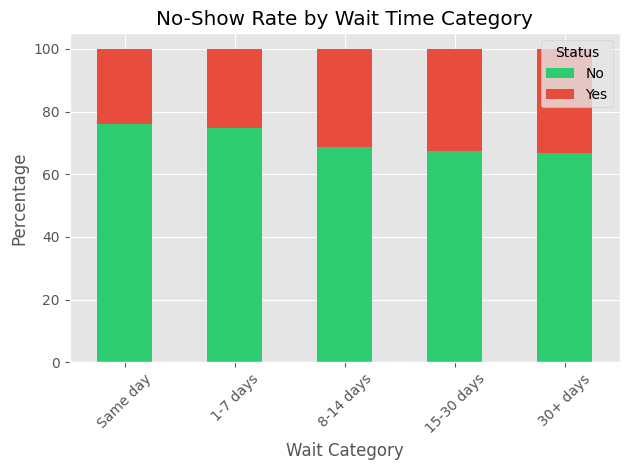

In [63]:
bins = [0, 1, 7, 14, 30, 100]
labels = ['Same day', '1-7 days', '8-14 days', '15-30 days', '30+ days']
data['WaitCategory'] = pd.cut(data['WaitDays'], bins=bins, labels=labels)
wait_churn = pd.crosstab(data['WaitCategory'], data['No-show'], normalize='index') * 100

plt.figure(figsize=(8,5))
wait_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'])
plt.title('No-Show Rate by Wait Time Category')
plt.ylabel('Percentage')
plt.xlabel('Wait Category')
plt.xticks(rotation=45)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

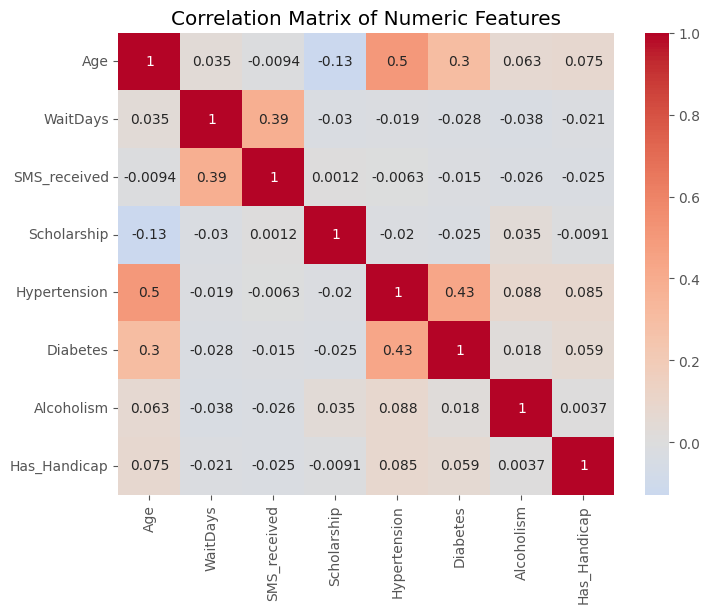

In [64]:
# Correlation heatmap of numeric features
numeric_cols = ['Age', 'WaitDays', 'SMS_received', 'Scholarship','Hypertension', 'Diabetes', 'Alcoholism', 'Has_Handicap']
plt.figure(figsize=(8,6))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

<Figure size 600x400 with 0 Axes>

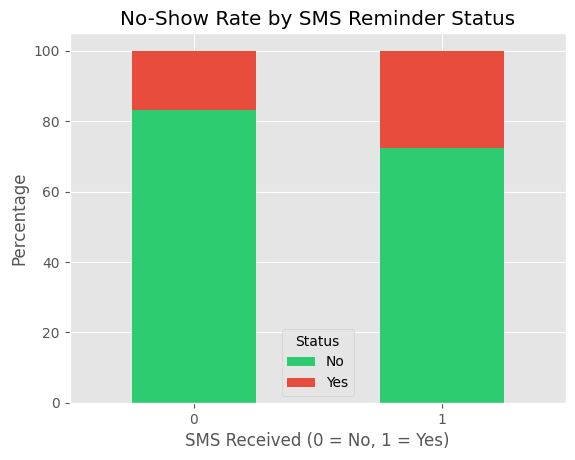

In [65]:
#sms received analysis
sms_churn = pd.crosstab(data['SMS_received'], data['No-show'], normalize='index') * 100

plt.figure(figsize=(6,4))
sms_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'])
plt.title('No-Show Rate by SMS Reminder Status')
plt.xlabel('SMS Received (0 = No, 1 = Yes)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.show()

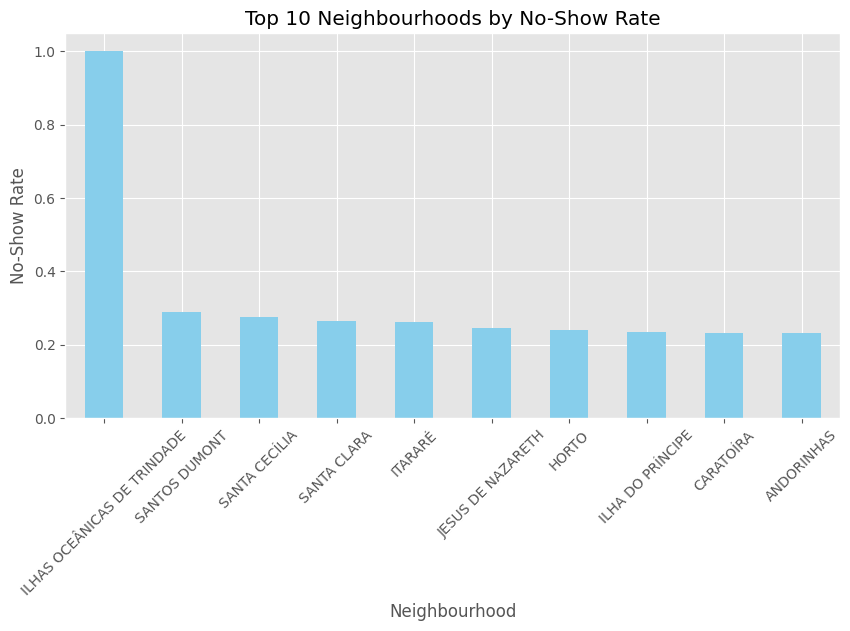

In [66]:
# Top 10 neighbourhoods with highest no-show rate
neighbourhood_churn = data.groupby('Neighbourhood')['No-show'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
neighbourhood_churn.plot(kind='bar', color='skyblue')
plt.title('Top 10 Neighbourhoods by No-Show Rate')
plt.ylabel('No-Show Rate')
plt.xlabel('Neighbourhood')
plt.xticks(rotation=45)
plt.show()

In [67]:
print(f"No-Show rate without SMS: {data[data['SMS_received']==0]['No-show'].value_counts(normalize=True)['Yes']*100:.2f}%")
print(f"No-Show rate with SMS: {data[data['SMS_received']==1]['No-show'].value_counts(normalize=True)['Yes']*100:.2f}%")


No-Show rate without SMS: 16.70%
No-Show rate with SMS: 27.57%


<Figure size 600x400 with 0 Axes>

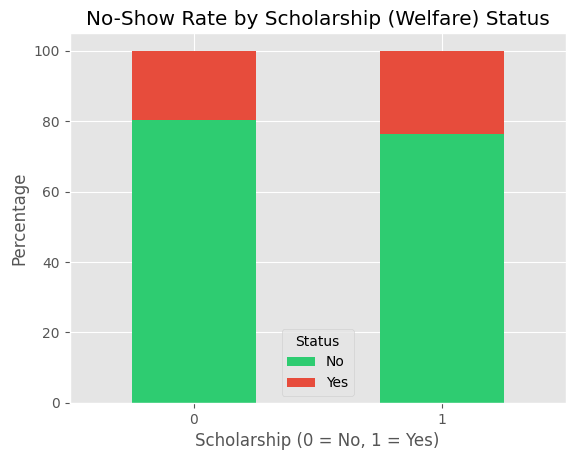

In [68]:
#scholarship (welfare) analysis
scholarship_churn = pd.crosstab(data['Scholarship'], data['No-show'], normalize='index') * 100

plt.figure(figsize=(6,4))
scholarship_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'])
plt.title('No-Show Rate by Scholarship (Welfare) Status')
plt.xlabel('Scholarship (0 = No, 1 = Yes)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.show()

<Figure size 600x400 with 0 Axes>

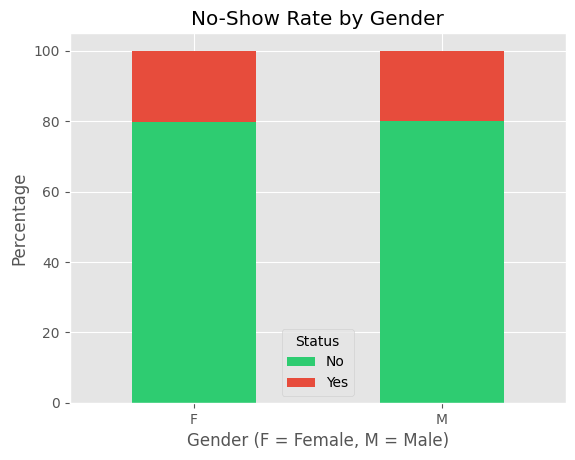

In [69]:
#gender analysis
gender_churn = pd.crosstab(data['Gender'], data['No-show'], normalize='index') * 100

plt.figure(figsize=(6,4))
gender_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'])
plt.title('No-Show Rate by Gender')
plt.xlabel('Gender (F = Female, M = Male)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.show()

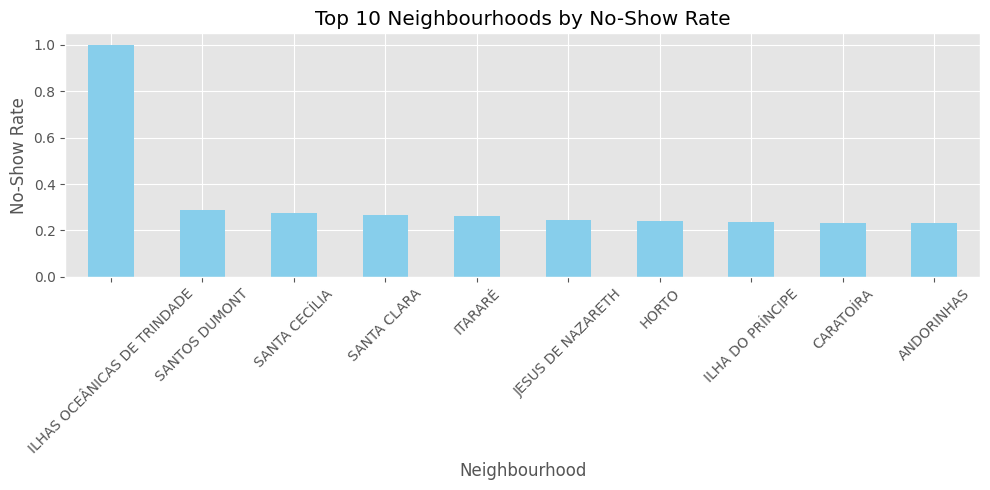

In [70]:
neighbourhood_churn = data.groupby('Neighbourhood')['No-show'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
neighbourhood_churn.plot(kind='bar', color='skyblue')
plt.title('Top 10 Neighbourhoods by No-Show Rate')
plt.ylabel('No-Show Rate')
plt.xlabel('Neighbourhood')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Feature Engineering & Selection


In [71]:
# target variable encoding and feature selection
X = data[['Gender', 'Age', 'Scholarship', 'Hypertension', 'Diabetes','Alcoholism', 'SMS_received', 'WaitDays', 'Has_Handicap']]
y = data['No-show']

In [72]:
X['Gender'] = X['Gender'].map({'F': 1, 'M': 0})
y = y.map({'Yes': 1, 'No': 0})

In [73]:
from sklearn.model_selection import train_test_split, GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [74]:
#fit transfromer on training data and transform both train and test data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
#save scaled data
import joblib
joblib.dump(scaler, 'healthcare_scaler.pkl')

['healthcare_scaler.pkl']

In [76]:
# Function to evaluate model performance
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"{model_name} Accuracy: {accuracy:.4f}")
    
    # Classification report
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_test, predictions, target_names=['Showed', 'No-Show']))
    
    return accuracy, predictions

In [77]:
# Model 1: Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

logistic_params = {
    'classifier__C': [0.1, 1, 10],
    'classifier__solver': ['liblinear', 'lbfgs'],
    'classifier__max_iter': [100, 200]
}

logistic_grid = GridSearchCV(logistic_pipeline, logistic_params, cv=5, scoring='accuracy')
logistic_grid.fit(X_train_scaled, y_train)

print(f"Best Logistic Regression parameters: {logistic_grid.best_params_}")
logistic_accuracy, logistic_pred = evaluate_model(logistic_grid, X_test_scaled, y_test, "Logistic Regression")

Best Logistic Regression parameters: {'classifier__C': 0.1, 'classifier__max_iter': 100, 'classifier__solver': 'liblinear'}
Logistic Regression Accuracy: 0.7958

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

      Showed       0.80      0.99      0.89     17642
     No-Show       0.36      0.01      0.03      4464

    accuracy                           0.80     22106
   macro avg       0.58      0.50      0.46     22106
weighted avg       0.71      0.80      0.71     22106



In [78]:
# Model 2: K-Nearest Neighbors (optimized)
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

# Reduced parameter grid – fewer neighbors, fewer metrics
knn_params = {
    'classifier__n_neighbors': [5, 10, 15],          
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean']             
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,           # use all CPU cores
    verbose=1            # show progress
)

print("Training KNN... (this may take a few minutes)")
knn_grid.fit(X_train_scaled, y_train)

print(f"Best KNN parameters: {knn_grid.best_params_}")
knn_accuracy, knn_pred = evaluate_model(knn_grid, X_test_scaled, y_test, "KNN")

Training KNN... (this may take a few minutes)
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best KNN parameters: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 10, 'classifier__weights': 'uniform'}
KNN Accuracy: 0.7874

Classification Report for KNN:
              precision    recall  f1-score   support

      Showed       0.80      0.97      0.88     17642
     No-Show       0.36      0.07      0.11      4464

    accuracy                           0.79     22106
   macro avg       0.58      0.52      0.50     22106
weighted avg       0.71      0.79      0.72     22106



In [79]:
# Model 3: LinearSVC
from sklearn.svm import LinearSVC

svm_linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LinearSVC(random_state=42, max_iter=2000, dual='auto'))
])

svm_linear_params = {
    'classifier__C': [0.1, 1, 10],          # regularisation
}

svm_grid = GridSearchCV(
    svm_linear_pipeline,
    svm_linear_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Training LinearSVC... (should be fast)")
svm_grid.fit(X_train_scaled, y_train)

print(f"Best LinearSVC parameters: {svm_grid.best_params_}")
svm_accuracy, svm_linear_pred = evaluate_model(svm_grid, X_test_scaled, y_test, "LinearSVC")

Training LinearSVC... (should be fast)
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best LinearSVC parameters: {'classifier__C': 0.1}
LinearSVC Accuracy: 0.7966

Classification Report for LinearSVC:
              precision    recall  f1-score   support

      Showed       0.80      1.00      0.89     17642
     No-Show       0.33      0.01      0.01      4464

    accuracy                           0.80     22106
   macro avg       0.56      0.50      0.45     22106
weighted avg       0.70      0.80      0.71     22106



In [80]:
# Model 4: Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_params = {
    'classifier__max_depth': [3, 5, 7, 10, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(dt_pipeline, dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train_scaled, y_train)

print(f"Best Decision Tree parameters: {dt_grid.best_params_}")
dt_accuracy, dt_pred = evaluate_model(dt_grid, X_test_scaled, y_test, "Decision Tree")

Best Decision Tree parameters: {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Decision Tree Accuracy: 0.7981

Classification Report for Decision Tree:
              precision    recall  f1-score   support

      Showed       0.80      1.00      0.89     17642
     No-Show       0.00      0.00      0.00      4464

    accuracy                           0.80     22106
   macro avg       0.40      0.50      0.44     22106
weighted avg       0.64      0.80      0.71     22106



In [ ]:
# Model 5: Random Forest 
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_params = {
    'classifier__n_estimators': [50, 100],        
    'classifier__max_depth': [10, 20, None],      
    'classifier__min_samples_split': [2, 5]       
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Training Random Forest... (this may take a few minutes)")
rf_grid.fit(X_train_scaled, y_train)

print(f"Best Random Forest parameters: {rf_grid.best_params_}")
rf_accuracy, rf_pred = evaluate_model(rf_grid, X_test_scaled, y_test, "Random Forest")

Training Random Forest... (this may take a few minutes)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Random Forest parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
Random Forest Accuracy: 0.7984

Classification Report for Random Forest:
              precision    recall  f1-score   support

      Showed       0.80      1.00      0.89     17642
     No-Show       0.56      0.01      0.02      4464

    accuracy                           0.80     22106
   macro avg       0.68      0.50      0.45     22106
weighted avg       0.75      0.80      0.71     22106




MODEL COMPARISON RESULTS
                 Model  Accuracy
4        Random Forest  0.798426
3        Decision Tree  0.798064
2                  SVM  0.796571
0  Logistic Regression  0.795847
1                  KNN  0.787388


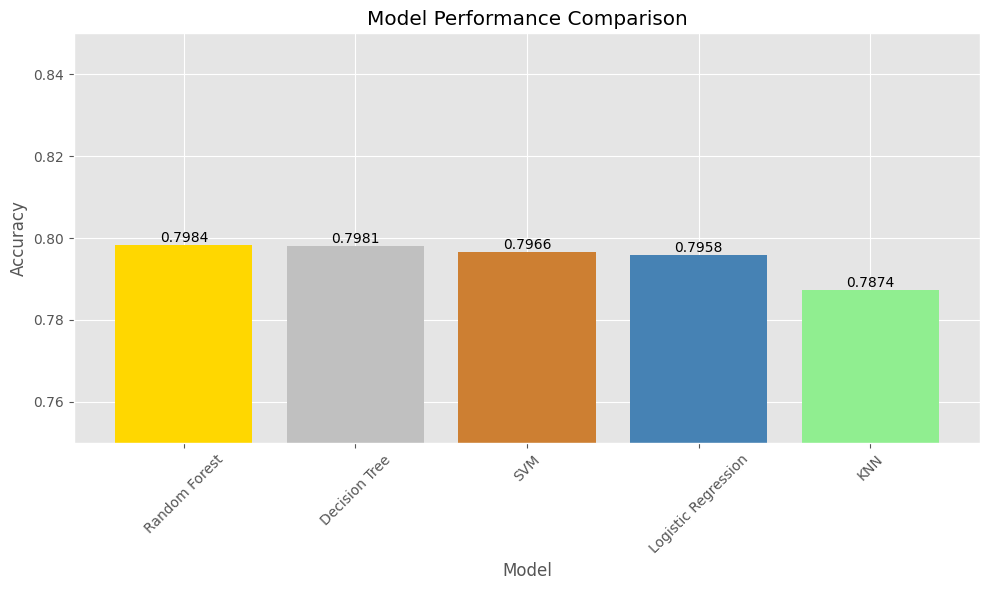


✅ Best model: Random Forest with accuracy: 0.7984


In [82]:
# Compare all models
models = ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree', 'Random Forest']
accuracies = [logistic_accuracy, knn_accuracy, svm_accuracy, dt_accuracy, rf_accuracy]

comparison_df = pd.DataFrame({'Model': models, 'Accuracy': accuracies})
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
print("\n" + "="*50)
print("MODEL COMPARISON RESULTS")
print("="*50)
print(comparison_df)

# Plot comparison
plt.figure(figsize=(10,6))
bars = plt.bar(comparison_df['Model'], comparison_df['Accuracy'], 
               color=['gold', 'silver', '#cd7f32', 'steelblue', 'lightgreen'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim([0.75, 0.85])

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Select best model
best_model_name = comparison_df.iloc[0]['Model']
best_accuracy = comparison_df.iloc[0]['Accuracy']
print(f"\n✅ Best model: {best_model_name} with accuracy: {best_accuracy:.4f}")

In [83]:
# Save the best model
import joblib

# Assign best model based on performance
if best_model_name == 'Logistic Regression':
    best_model = logistic_grid.best_estimator_
elif best_model_name == 'KNN':
    best_model = knn_grid.best_estimator_
elif best_model_name == 'SVM':
    best_model = svm_grid.best_estimator_
elif best_model_name == 'Decision Tree':
    best_model = dt_grid.best_estimator_
else:
    best_model = rf_grid.best_estimator_

# Save model and scaler
joblib.dump(best_model, 'healthcare_model.pkl')
joblib.dump(scaler, 'healthcare_scaler.pkl')

print("Best model saved as 'healthcare_model.pkl'")
print("Scaler saved as 'healthcare_scaler.pkl'")

Best model saved as 'healthcare_model.pkl'
Scaler saved as 'healthcare_scaler.pkl'
